<a href="https://colab.research.google.com/github/JJCG25/Chagas---Machine-Learning/blob/main/Entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRERIAS**

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS


In [ ]:
!pip install catboost -q
!pip install lightgbm -q
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import numpy as np
from xgboost import plot_importance, XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# **CARGADO Y LIMPIEZA**

In [ ]:
path= 'Base_tesis_chagas_IA_250725.xlsx'
df = pd.read_excel(path)
df.drop(columns=["Primera dosis","segunda dosis","Tercera dosis","Cuarta dosis", 'Vacunación COVID',
                 'Tipo vacuna',"Mortalidad tiempo","Fuma actualmente", "número de cigarrillos diarios",
                 "Años de fumador", 'IMCat','Tipo vacuna.1','Tipo vacuna.2','Tipo vacuna.3','cod',
                 'fechaingreso', 'anioingreso', 'Fecha aplicación','Fecha aplicación.1',
                 'Fecha aplicación.2','Fecha aplicación.3', 'Fecha mortalidad', 'Fecha trasplante',
                 'Fecha asistencia'], inplace=True)

df = df.drop(index=1036)
df["IPA"] = df["IPA"].fillna(0)
df = pd.get_dummies(df, columns=['AHA', 'NYHA','estadocivil','arearesidencia','regimensalud','educacion'])

cols_to_fix = ["ind vol final sistole", "índice E/E", "velocidad E´","diametro AI","TAPSE","presion sVD","índice de masa miocárdica","indice vol final diastole"]
for col in cols_to_fix:
  df.loc[df[col] == 0, col] = np.nan

In [ ]:
df.drop(columns=['índice E/E','velocidad E´','presion sVD','Complicaciones total',
                 'Asistencia','Trasplante','ACV','Mortalidad','Mortalidad menor a 2 años'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 78 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    1036 non-null   float64
 1   edad                                              1036 non-null   float64
 2   sexo                                              1036 non-null   float64
 3   IPA                                               1036 non-null   float64
 4   Consumo alcohol                                   1036 non-null   float64
 5   Peso                                              1036 non-null   float64
 6   Talla                                             1036 non-null   float64
 7   IMC                                               1036 non-null   float64
 8   FC                                                1036 non-null   float64
 9   PAS                

# **SPLITS**

## **Solo Columnas completas**

In [ ]:
df_full = df.dropna(axis=1)
df_full.info()

X = df_full.drop(columns=['Complicaciones cardiovasculares'])
y = df_full['Complicaciones cardiovasculares']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   tipodepaciente                   1036 non-null   float64
 1   edad                             1036 non-null   float64
 2   sexo                             1036 non-null   float64
 3   estadocivil                      1036 non-null   float64
 4   arearesidencia                   1036 non-null   float64
 5   regimensalud                     1036 non-null   float64
 6   educacion                        1036 non-null   float64
 7   IPA                              1036 non-null   float64
 8   Consumo alcohol                  1036 non-null   float64
 9   Peso                             1036 non-null   float64
 10  Talla                            1036 non-null   float64
 11  IMC                              1036 non-null   float64
 12  FC                  

In [ ]:
#Distribucion de pacientes
df_full['Complicaciones cardiovasculares'].value_counts()

,count
Complicaciones cardiovasculares,
0.0000,974
1.0000,62


## **Rellenado con media**

In [ ]:
X = df.drop(columns=['Complicaciones cardiovasculares'])
y = df['Complicaciones cardiovasculares']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === Imputación sin data leakage ===
train_means = X_train.mean(numeric_only=True)
X_train = X_train.fillna(train_means)

test_means = X_test.mean(numeric_only=True)
X_test = X_test.fillna(train_means)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 828 entries, 196 to 768
Data columns (total 69 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    828 non-null    float64
 1   edad                                              828 non-null    float64
 2   sexo                                              828 non-null    float64
 3   estadocivil                                       828 non-null    float64
 4   arearesidencia                                    828 non-null    float64
 5   regimensalud                                      828 non-null    float64
 6   educacion                                         828 non-null    float64
 7   IPA                                               828 non-null    float64
 8   Consumo alcohol                                   828 non-null    float64
 9   Peso                    

In [ ]:
#Distribucion de pacientes
df_full['Complicaciones cardiovasculares'].value_counts()

,count
Complicaciones cardiovasculares,
0.0000,974
1.0000,62


## **Undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

X = df.drop(columns=['Complicaciones cardiovasculares'])
y = df['Complicaciones cardiovasculares']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_means = X_train.mean(numeric_only=True)
X_train = X_train.fillna(train_means)

test_means = X_test.mean(numeric_only=True)
X_test = X_test.fillna(train_means)

# --- Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

## **Oversampling**

In [ ]:
from imblearn.over_sampling import RandomOverSampler

X = df.drop(columns=['Complicaciones cardiovasculares'])
y = df['Complicaciones cardiovasculares']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_means = X_train.mean(numeric_only=True)
X_train = X_train.fillna(train_means)

#test_means = X_test.mean(numeric_only=True)
X_test = X_test.fillna(train_means)

sampler = RandomOverSampler(random_state=42)
X_train, y_train = sampler.fit_resample(X_train, y_train)

In [ ]:
y_train.value_counts()

,count
Complicaciones cardiovasculares,
0.0000,778
1.0000,778


## **SMOTE**

In [ ]:
df_fill_mean = df.fillna(df.mean(numeric_only=True))

X = df_fill_mean.drop(columns=['tipodepaciente'])
y = df_fill_mean['tipodepaciente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)



print(y_train.value_counts())

print(y_train_res.value_counts())

#df_fill_mean.info()

tipodepaciente
1.0    752
0.0     76
Name: count, dtype: int64
tipodepaciente
1.0    752
0.0    752
Name: count, dtype: int64


# **ENTRANAMIENTOS**

## **Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))

                   precision    recall  f1-score   support

No Complicaciones       0.96      0.48      0.64       196
   Complicaciones       0.07      0.67      0.13        12

         accuracy                           0.50       208
        macro avg       0.52      0.58      0.39       208
     weighted avg       0.91      0.50      0.61       208



In [ ]:
#@title Feature Importance
importancias_dt = dt.feature_importances_

feat_importances_dt = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importancias_dt
    })
    .query("Importance > 0")  # ← filtra las que no sean 0
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

print("Feature importance of Decision Tree")
print(feat_importances_dt.to_string(index=False))

# Mostrar la suma total de las importancias
total_importance = feat_importances_dt["Importance"].sum()
print(f"\nTotal importance sum: {total_importance:.6f}")

Feature importance of Decision Tree
               Feature  Importance
 ind vol final sistole      0.3426
         Heoglobina 1       0.1982
                   PCR      0.1482
Neutrofilos porcentaje      0.1202
           diametro AI      0.1084
                    FC      0.0825

Total importance sum: 1.000000


## **KNN**

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors= 5,
    p= 1,
    weights= 'uniform'
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("Classification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))

Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.96      0.48      0.64       196
   Complicaciones       0.07      0.67      0.13        12

         accuracy                           0.50       208
        macro avg       0.52      0.58      0.39       208
     weighted avg       0.91      0.50      0.61       208



In [ ]:
#@title Feature Importance
# Calcular importancias por permutación
result = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

# Crear DataFrame
perm_importances_knn = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

# Filtrar las features con importancia > 0
perm_importances_knn = perm_importances_knn[perm_importances_knn["Importance"] > 0]

# Normalizar importancias para que sumen 1
total = perm_importances_knn["Importance"].sum()
if total != 0:
    perm_importances_knn["Importance"] /= total

# Ordenar de mayor a menor
perm_importances_knn = perm_importances_knn.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Mostrar resultados
print("Feature importance of KNN (non-zero & normalized):")
print(perm_importances_knn.to_string(index=False))

# Mostrar suma total para confirmar normalización
print(f"\nTotal importance sum: {perm_importances_knn['Importance'].sum():.6f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning

Feature importance of KNN (non-zero & normalized):
Empty DataFrame
Columns: [Feature, Importance]
Index: []

Total importance sum: 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


## **SVM**

In [ ]:
svm_rbf = SVC(
    kernel="rbf",
    probability=True,
    random_state=42,
    C = 1,
    class_weight="balanced",
    gamma= 'scale')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_rbf.fit(X_train_scaled, y_train)

y_pred = svm_rbf.predict(X_test_scaled)
print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.95      0.98      0.96       196
   Complicaciones       0.20      0.08      0.12        12

         accuracy                           0.93       208
        macro avg       0.57      0.53      0.54       208
     weighted avg       0.90      0.93      0.91       208



In [ ]:
#@title Desition border
'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

svm_rbf = SVC(
    kernel="linear",
    probability=True,
    random_state=42,
    C=1000,
    gamma='scale'
)
svm_rbf.fit(X_train_2D, y_train)

y_pred = svm_rbf.predict(X_test_2D)
print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))
# Visualización del decision boundary
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predicción sobre el grid
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_2D[:, 0], X_train_2D[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=40, label='Train')
plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, cmap='coolwarm', marker='x', s=60, label='Test')

plt.title("Frontera de decisión del SVM (linear) con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()
'''

'\nscaler = StandardScaler()\nX_scaled = scaler.fit_transform(X)\nX_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)\n\npca = PCA(n_components=2)\nX_train_2D = pca.fit_transform(X_train)\nX_test_2D = pca.transform(X_test)\n\nsvm_rbf = SVC(\n    kernel="linear",\n    probability=True,\n    random_state=42,\n    C=1000,\n    gamma=\'scale\'\n)\nsvm_rbf.fit(X_train_2D, y_train)\n\ny_pred = svm_rbf.predict(X_test_2D)\nprint("\nClassification Report en Test:")\nprint(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))\n# Visualización del decision boundary\nx_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1\ny_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1\nxx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),\n                     np.linspace(y_min, y_max, 300))\n\n# Predicción sobre el grid\nZ = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])\nZ = Z.resh

In [ ]:
#@title Feature Importance

result = permutation_importance(svm_rbf, X_test, y_test, n_repeats=10, random_state=42)

# Crear DataFrame
perm_importances_svm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

# Tomar valor absoluto (en caso de importancias negativas)
perm_importances_svm["Importance"] = perm_importances_svm["Importance"].abs()

# Filtrar solo las features con importancia > 0
perm_importances_svm = perm_importances_svm[perm_importances_svm["Importance"] > 0]

# Normalizar para que sumen 1
total = perm_importances_svm["Importance"].sum()
if total != 0:
    perm_importances_svm["Importance"] /= total

# Ordenar
perm_importances_svm = perm_importances_svm.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Mostrar resultados
print("Feature importance of SVM:")
print(perm_importances_svm.to_string(index=False))

# Verificar suma total
print(f"\nTotal importance sum: {perm_importances_svm['Importance'].sum():.6f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr

Feature importance of SVM:
Empty DataFrame
Columns: [Feature, Importance]
Index: []

Total importance sum: 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr

## **Random Forest**

In [ ]:
rf = RandomForestClassifier(
    max_depth= None,
    max_features= 'sqrt',
    min_samples_leaf= 1,
    min_samples_split= 5,
    n_estimators=300,
    class_weight='balanced',
    random_state=42)


rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.94      1.00      0.97       196
   Complicaciones       0.00      0.00      0.00        12

         accuracy                           0.94       208
        macro avg       0.47      0.50      0.49       208
     weighted avg       0.89      0.94      0.91       208



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#@title Feature Importance para Random Forest
importancias = rf.feature_importances_
feat_importances_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importancias
})

# Filtrar solo las features con importancia > 0
feat_importances_rf = feat_importances_rf[feat_importances_rf["Importance"] > 0]

# Normalizar importancias
total = feat_importances_rf["Importance"].sum()
if total != 0:
    feat_importances_rf["Importance"] /= total

# Ordenar de mayor a menor
feat_importances_rf = feat_importances_rf.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Mostrar resultados
print("Feature importance of Random Forest:")
print(feat_importances_rf.to_string(index=False))

# Verificar suma total
print(f"\nTotal importance sum: {feat_importances_rf['Importance'].sum():.6f}")


Feature importance of Random Forest:
                                         Feature  Importance
                           ind vol final sistole      0.0459
                                   Heoglobina 1       0.0408
                                      creatinina      0.0387
                                   Leucocitos 1       0.0353
                                             PCR      0.0327
                                            fevi      0.0321
                                           Talla      0.0305
                                             IMC      0.0290
                                         potasio      0.0285
                                     diametro AI      0.0271
                                            Peso      0.0255
                            Monocitos porcentaje      0.0253
                                             BUN      0.0239
                          Eosinofilos porcentaje      0.0235
                                            edad

## **Bagging**

In [ ]:
# Deje los hiperparametros del mejor tree de arriba
base_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf= 1,
    class_weight='balanced',
    random_state=42
)

# Bagging con árboles como base
bagging = BaggingClassifier(
    estimator=base_tree,
    max_features= 0.8,
    max_samples= 0.8,
    n_estimators= 50,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.97      0.70      0.82       196
   Complicaciones       0.12      0.67      0.21        12

         accuracy                           0.70       208
        macro avg       0.55      0.69      0.51       208
     weighted avg       0.92      0.70      0.78       208



In [ ]:
#@title Feature Importance
r = permutation_importance(bagging, X_test, y_test, n_repeats=10, random_state=42)

feat_importances_perm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": r.importances_mean
}).sort_values(by="Importance", ascending=False)

feat_importances_perm = feat_importances_perm[feat_importances_perm["Importance"] > 0]

# Normalizar importancias
total = feat_importances_perm["Importance"].sum()
if total != 0:
    feat_importances_perm["Importance"] /= total


print('Feature importance of Bagging:')
print(feat_importances_perm.to_string())

print(f"\nTotal importance sum: {feat_importances_perm['Importance'].sum():.6f}")

Feature importance of Bagging:
                                             Feature  Importance
26                                        creatinina      0.1806
18                                Fibrilación atrial      0.1639
32                                     Leucocitos 1       0.1000
29                                               PCR      0.0556
30                                               BUN      0.0500
57                                       diametro AI      0.0500
22                                              fevi      0.0472
48                              Monocitos porcentaje      0.0472
55                             ind vol final sistole      0.0472
11                                               IMC      0.0389
59                         índice de masa miocárdica      0.0333
12                                                FC      0.0333
49                            Eosinofilos porcentaje      0.0306
35                       Volumen Corpuscular Medio 1      0

## **AdaBoost**

In [ ]:
base_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf= 1,
    random_state=42
)

adaboost = AdaBoostClassifier(
    estimator=base_tree,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)

adaboost.fit(X_train, y_train)

y_pred = adaboost.predict(X_test)
print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.96      0.74      0.84       196
   Complicaciones       0.11      0.50      0.18        12

         accuracy                           0.73       208
        macro avg       0.53      0.62      0.51       208
     weighted avg       0.91      0.73      0.80       208



In [ ]:
#@title Feature Importance (AdaBoost)

# Obtener importancias desde el modelo entrenado
importancias = adaboost.feature_importances_

# Crear DataFrame ordenado
feat_importances_adaboost = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importancias
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Umbral mínimo para considerar una importancia significativa
threshold = 0.0001

# Filtrar solo las features con importancia > umbral
feat_importances_adaboost = feat_importances_adaboost[feat_importances_adaboost["Importance"] > threshold]

# Normalizar importancias para que sumen 1
total = feat_importances_adaboost["Importance"].sum()
if total != 0:
    feat_importances_adaboost["Importance"] /= total

# Redondear valores a 4 decimales
feat_importances_adaboost["Importance"] = feat_importances_adaboost["Importance"].round(4)

# Mostrar resultados
print("Feature importance of AdaBoost:")
print(feat_importances_adaboost.to_string(index=False))

# Verificar suma total (debe ser 1)
print(f"\nTotal importance sum: {feat_importances_adaboost['Importance'].sum():.6f}")

Feature importance of AdaBoost:
                                         Feature  Importance
                           ind vol final sistole      0.2191
                                   Heoglobina 1       0.0826
                                             PCR      0.0750
                                     diametro AI      0.0681
                                            Peso      0.0491
                          Neutrofilos porcentaje      0.0434
                                     hematocrito      0.0415
                                           Talla      0.0407
                                   Leucocitos 1       0.0369
                                              BB      0.0364
                                              FC      0.0361
                                        glicemia      0.0347
                                      creatinina      0.0308
                                     Basofilos 1      0.0258
                          Eosinofilos porcentaje     

## **XGBoost**

In [ ]:
xgb = XGBClassifier(
    objective="binary:logistic",  # porque tienes dos clases (0 y 1)
    eval_metric="logloss",
    colsample_bytree= 0.8,
    gamma= 1,
    learning_rate= 0.1,
    max_depth=3,
    n_estimators= 100,
    subsample= 1.0,
    scale_pos_weight = 974/62, #≈ 15.7
    random_state=42

)


xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.95      0.84      0.89       196
   Complicaciones       0.11      0.33      0.17        12

         accuracy                           0.81       208
        macro avg       0.53      0.59      0.53       208
     weighted avg       0.90      0.81      0.85       208



In [ ]:
#@title Feature Importance
importancias = xgb.feature_importances_

importancias_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importancias
}).sort_values(by="Importance", ascending=False)

print('Feature importance of XGBoost:')
print(importancias_xgb[importancias_xgb["Importance"] > 0].to_string())

print(f'\nTotal importance sum: {importancias_xgb["Importance"].sum():.6f}')

Feature importance of XGBoost:
                                             Feature  Importance
45                                       Basofilos 1      0.0619
55                             ind vol final sistole      0.0617
34                                       hematocrito      0.0445
29                                               PCR      0.0423
33                                     Heoglobina 1       0.0415
10                                             Talla      0.0348
24                                                BB      0.0294
46                            Neutrofilos porcentaje      0.0275
26                                        creatinina      0.0258
32                                     Leucocitos 1       0.0255
30                                               BUN      0.0240
35                       Volumen Corpuscular Medio 1      0.0238
47                             Linfocitos porcentaje      0.0230
41                                     Neutrofilos 1      0

## **CatBoost**

In [ ]:
cat = CatBoostClassifier(
    verbose=0,
    random_state=42,
    bagging_temperature= 0,
    depth= 6,
    iterations= 500,
    l2_leaf_reg= 1,
    scale_pos_weight = 974/62, #≈ 15.7
    learning_rate= 0.1
)


cat.fit(X_train, y_train)
y_pred = cat.predict(X_test)

print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.95      0.90      0.93       196
   Complicaciones       0.14      0.25      0.18        12

         accuracy                           0.87       208
        macro avg       0.54      0.58      0.55       208
     weighted avg       0.90      0.87      0.88       208



In [ ]:
#@title Feature Importance

importancias = cat.feature_importances_

feat_importances_cat = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importancias
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Filtrar valores muy pequeños
threshold = 0.001

# Normalizar (para que sumen exactamente 1)
total = feat_importances_cat["Importance"].sum()
if total != 0:
    feat_importances_cat["Importance"] = feat_importances_cat["Importance"] / total

print("Feature importance of CatBoost: ")
print(feat_importances_cat[feat_importances_cat["Importance"] > threshold].to_string())

print(f"\nTotal importance sum: {feat_importances_cat['Importance'].sum():.6f}")

Feature importance of CatBoost: 
                                             Feature  Importance
0                                      Heoglobina 1       0.0466
1                                               fevi      0.0464
2                                                IMC      0.0429
3                                         creatinina      0.0389
4                              ind vol final sistole      0.0371
5                                                 FC      0.0320
6                                                PCR      0.0308
7                                              Talla      0.0303
8                                                PAS      0.0273
9                                               edad      0.0264
10                                         NT proBNP      0.0258
11                                               BUN      0.0252
12                                           potasio      0.0228
13                                 diametro diastole     

## **LightGBM**

In [ ]:
lgbm = LGBMClassifier(
    random_state=42,
    importance_type='gain',
    learning_rate= 0.05,
    max_depth= -1,
    n_estimators= 300,
    num_leaves= 63,
    scale_pos_weight = 974/62, #≈ 15.7
    verbose=-1 )

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)
print("\nClassification Report en Test:")
print(classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"]))


Classification Report en Test:
                   precision    recall  f1-score   support

No Complicaciones       0.95      0.99      0.97       196
   Complicaciones       0.33      0.08      0.13        12

         accuracy                           0.94       208
        macro avg       0.64      0.54      0.55       208
     weighted avg       0.91      0.94      0.92       208



In [ ]:
importancias = lgbm.feature_importances_

importancias_lgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importancias
}).sort_values(by="Importance", ascending=False)

total = importancias_lgb["Importance"].sum()
if total != 0:
    importancias_lgb["Importance"] = importancias_lgb["Importance"] / total

print('Feature importance of LightGBM:')
print(importancias_lgb[importancias_lgb["Importance"] > threshold])

print(f"\nTotal importance sum: {importancias_lgb['Importance'].sum():.6f}")

Feature importance of LightGBM:
                                             Feature  Importance
55                             ind vol final sistole      0.1485
12                                                FC      0.0693
29                                               PCR      0.0672
11                                               IMC      0.0562
47                             Linfocitos porcentaje      0.0458
48                              Monocitos porcentaje      0.0364
30                                               BUN      0.0328
27                                           potasio      0.0310
32                                     Leucocitos 1       0.0310
33                                     Heoglobina 1       0.0309
26                                        creatinina      0.0308
57                                       diametro AI      0.0269
41                                     Neutrofilos 1      0.0251
49                            Eosinofilos porcentaje      

## **REPORTE TOTAL**

In [ ]:
# Diccionario para almacenar resultados
resultados = {}

def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:,1] if hasattr(modelo, "predict_proba") else None

    # Classification Report (macro avg)
    report = classification_report(y_test, y_pred, target_names=["No Complicaciones", "Complicaciones"],output_dict=True)
    precision = report["No Complicaciones"]["precision"]
    recall = report["Complicaciones"]["recall"]
    f1 = report["macro avg"]["f1-score"]
    accuracy = report["accuracy"]

    # Specificity (especificidad)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    # AUC-ROC y PR-AUC si hay probabilidades
    auroc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    resultados[nombre] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Specificity": specificity,
        "AUROC": auroc,
        "PR-AUC": pr_auc
    }

# Ejemplo: evaluamos varios modelos
evaluar_modelo("Decision tree", dt, X_test, y_test)
evaluar_modelo("Random Forest", rf, X_test, y_test)
evaluar_modelo("SVM (RBF)", svm_rbf, X_test, y_test)
evaluar_modelo("XGBoost", xgb, X_test, y_test)
evaluar_modelo("LightGBM", lgbm, X_test, y_test)
evaluar_modelo("CatBoost", cat, X_test, y_test)
evaluar_modelo("AdaBoost", adaboost, X_test, y_test)
evaluar_modelo("Bagging (DT)", bagging, X_test, y_test)
evaluar_modelo("KNN", knn, X_test, y_test)

# Convertimos a DataFrame ordenado
df_resultados = pd.DataFrame(resultados).T
print(df_resultados.to_string())

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/u

               Accuracy  Precision  Recall  F1-Score  Specificity  AUROC  PR-AUC
Decision tree    0.4952     0.9596  0.6667    0.3881       0.4847 0.5757  0.0682
Random Forest    0.9423     0.9423  0.0000    0.4851       1.0000 0.7211  0.1414
SVM (RBF)        0.9423     0.9423  0.0000    0.4851       1.0000 0.5000  0.0577
XGBoost          0.8077     0.9535  0.3333    0.5290       0.8367 0.7423  0.2041
LightGBM         0.9375     0.9463  0.0833    0.5505       0.9898 0.7491  0.2090
CatBoost         0.8654     0.9516  0.2500    0.5516       0.9031 0.7168  0.1808
AdaBoost         0.7308     0.9605  0.5000    0.5078       0.7449 0.7066  0.1718
Bagging (DT)     0.7019     0.9718  0.6667    0.5108       0.7041 0.7258  0.3429
KNN              0.9423     0.9423  0.0000    0.4851       1.0000 0.5000  0.0577


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipython-input-1341431829.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


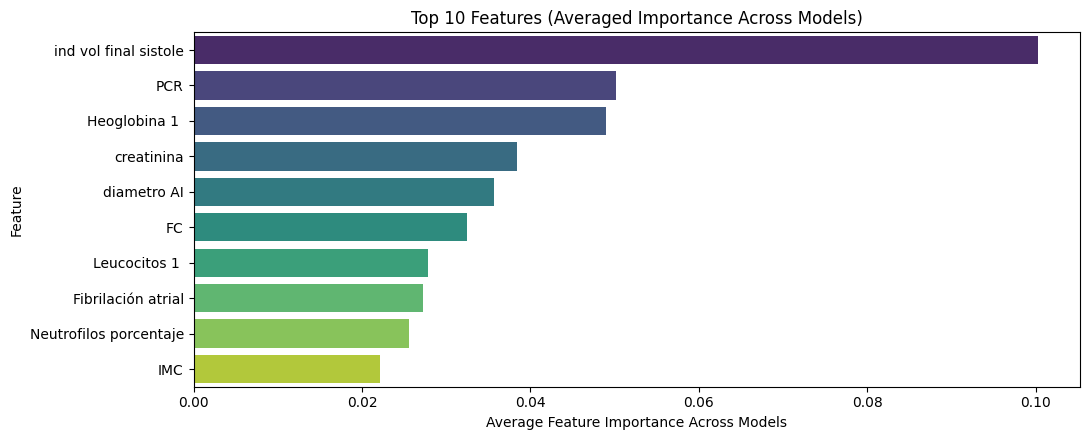

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Supongamos que ya tienes estas variables creadas ===
# importancias_lgb, importancias_rf, importancias_xgb, importancias_svm
# (cada una con columnas: "Feature", "Importance")

# Renombrar la columna de importancia para identificar el modelo
importancias_dt = feat_importances_dt.rename(columns={"Importance": "DecisionTree"})
importancias_knn = perm_importances_knn.rename(columns={"Importance": "KNN"})
importancias_svm = perm_importances_svm.rename(columns={"Importance": "SVM"})
importancias_rf = feat_importances_rf.rename(columns={"Importance": "RandomForest"})
importancias_bagging = feat_importances_perm.rename(columns={"Importance": "Bagging"})
importancias_adaboost = feat_importances_adaboost.rename(columns={"Importance": "Adaboost"})
importancias_xgb = importancias_xgb.rename(columns={"Importance": "XGBoost"})
importancias_cat = feat_importances_cat.rename(columns={"Importance": "CatBoost"})
importancias_lgb = importancias_lgb.rename(columns={"Importance": "LightGBM"})

# === Unir todos los DataFrames por la columna "Feature" ===
df_combined = (
    importancias_dt
    .merge(importancias_knn, on="Feature", how="outer")
    .merge(importancias_svm, on="Feature", how="outer")
    .merge(importancias_rf, on="Feature", how="outer")
    .merge(importancias_bagging, on="Feature", how="outer")
    .merge(importancias_adaboost, on="Feature", how="outer")
    .merge(importancias_xgb, on="Feature", how="outer")
    .merge(importancias_cat, on="Feature", how="outer")
    .merge(importancias_lgb, on="Feature", how="outer")
)

# Rellenar posibles NaN (por si algún modelo no tenía cierta feature)
df_combined = df_combined.fillna(0)

# === Calcular el promedio de importancias entre modelos ===
df_combined["Average"] = df_combined[["DecisionTree", "KNN","SVM", "RandomForest",
                                      "Bagging", "Adaboost", "XGBoost","CatBoost",
                                       "LightGBM"]].mean(axis=1)

# === Ordenar por importancia promedio y seleccionar el top 10 ===
top10 = df_combined.sort_values("Average", ascending=False).head(10)

# === Graficar ===
plt.figure(figsize=(11, 4.5))
sns.barplot(
    data=top10,
    x="Average",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Features (Averaged Importance Across Models)")
plt.xlabel("Average Feature Importance Across Models")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()